# Improving dark security images

Simple image filtering pipeline that can improve image quality

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Coefficients calculés : 2.0345027 63.403748


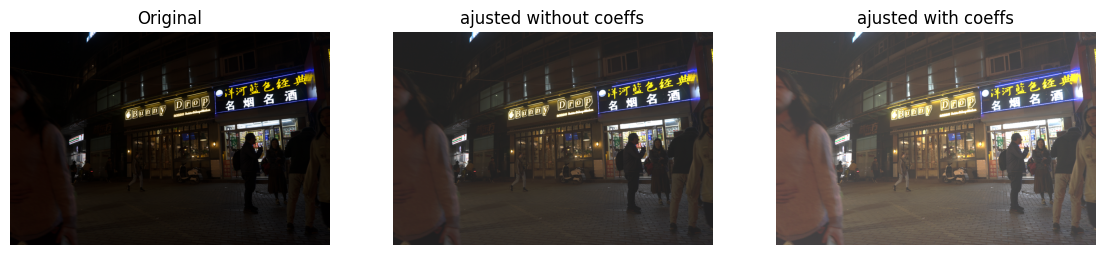

In [ ]:

def compute_linear_coeffs(img, target_mean=100, target_std=70):
    """
    Calcule alpha et beta pour transformer l'image afin que
    la moyenne des pixels approche target_mean et l'écart-type target_std.
    
    img : PIL.Image RGB
    target_mean : int, luminosité cible
    target_std : int, contraste cible
    """
    arr = np.array(img, dtype=np.float32)
    mean = arr.mean()
    std = arr.std()
    
    # alpha ajuste le contraste
    alpha = target_std / (std + 1e-5)
    
    # beta ajuste la luminosité
    beta = target_mean - alpha * mean
    
    return alpha, beta

def linear_adjust(img, alpha, beta):
    """
    Applique la transformation linéaire à une image RGB.
    
    img : PIL.Image RGB
    alpha : float, coefficient de contraste
    beta : float, décalage de luminosité
    """
    arr = np.array(img, dtype=np.float32)
    adjusted = np.clip(alpha * arr + beta, 0, 255).astype(np.uint8)
    return Image.fromarray(adjusted)

img = Image.open(r"data\image\4058.png").convert("RGB")


#Without coeffs adjusted
adjusted = linear_adjust(img, alpha=1.2, beta=30)

#With adjusted coeffs
alpha, beta = compute_linear_coeffs(img)
print("Coefficients calculés :", alpha, beta)
adjusted_coeff = linear_adjust(img, alpha, beta)

#Print
fig, axs = plt.subplots(1, 3, figsize=(14,8))

axs[0].imshow(img)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(adjusted)
axs[1].set_title("ajusted without coeffs")
axs[1].axis("off")

axs[2].imshow(adjusted_coeff)
axs[2].set_title("ajusted with coeffs")
axs[2].axis("off")

plt.show()


